# 4 · Approval and risk strategy

Illustrative approval policies use **validation prediction thresholds only**, then report the same fixed thresholds on the untouched test split. The baseline requests 50% validation-cohort approval. Ten percent more approvals relative requests 55%; ten percentage points more requests 60%. Actual approval rates can differ due to threshold ties and cohort differences.

In [1]:
from pathlib import Path
import os
import sys
import json
import pandas as pd
from IPython.display import display, Image, Markdown

# The executor supplies these paths. Interactive runs default to local exports.
ROOT = Path(os.environ.get('HOME_CREDIT_PROJECT_ROOT', str(Path.cwd()))).resolve()
if not (ROOT / 'src' / 'analysis.py').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.analysis import ensure_analysis, load_features, eda_tables

INPUT = Path(os.environ.get('HOME_CREDIT_FEATURES', str(ROOT / 'exports' / 'applicant_features.csv')))
OUTPUT = Path(os.environ.get('HOME_CREDIT_ANALYSIS', str(ROOT / 'outputs' / 'analysis')))
STATUS = os.environ.get('HOME_CREDIT_DATA_STATUS', 'real')
LGD = float(os.environ.get('HOME_CREDIT_LGD', '0.45'))
SEED = int(os.environ.get('HOME_CREDIT_SEED', '42'))
manifest = ensure_analysis(INPUT, OUTPUT, data_status=STATUS, lgd=LGD, seed=SEED)
get_ipython().run_line_magic('matplotlib', 'inline')
display(Markdown(f'**Data status: {manifest["data_status"].upper()}**. '
    + ('Synthetic pipeline validation; no Home Credit conclusions.' if STATUS != 'real'
       else 'Computed from the supplied accepted-cohort export.')))


**Data status: REAL**. Computed from the supplied accepted-cohort export.

,requested_validation_approval_rate,pd_cutoff,score_cutoff,threshold_source,approval_rule,validation_applicants,validation_approved_count,validation_approval_rate,validation_bad_count,validation_bad_rate,...,test_bad_rate_ci_high,test_expected_bad_rate,test_expected_loss,test_approved_known_ead_count,test_approved_missing_ead_count,test_expected_loss_coverage_rate,test_expected_loss_per_approved,test_expected_loss_per_approved_denominator,test_expected_loss_per_approved_known_ead,test_approved_ead
0,0.00,0.000000,1085.069933,validation_predictions,pd <= pd_cutoff,61502,0,0.000000,0,NaN,...,NaN,NaN,0.000000e+00,0,0,NaN,NaN,all approved; numerator is known-EAD EL subtotal,NaN,0.000000e+00
1,0.05,0.012849,612.394080,validation_predictions,pd <= pd_cutoff,61502,3076,0.050015,41,0.013329,...,0.014114,0.009630,1.080564e+07,3110,0,1.0,3474.481357,all approved; numerator is known-EAD EL subtotal,3474.481357,2.544506e+09
2,0.10,0.017348,603.599397,validation_predictions,pd <= pd_cutoff,61502,6151,0.100013,88,0.014307,...,0.014519,0.012372,2.583594e+07,6157,0,1.0,4196.189827,all approved; numerator is known-EAD EL subtotal,4196.189827,4.747794e+09
3,0.15,0.021400,597.424279,validation_predictions,pd <= pd_cutoff,61502,9226,0.150011,161,0.017451,...,0.016343,0.014632,4.365038e+07,9099,0,1.0,4797.272248,all approved; numerator is known-EAD EL subtotal,4797.272248,6.794793e+09
4,0.20,0.025470,592.279458,validation_predictions,pd <= pd_cutoff,61502,12301,0.200010,232,0.018860,...,0.018460,0.016838,6.458003e+07,12138,0,1.0,5320.483613,all approved; numerator is known-EAD EL subtotal,5320.483613,8.779415e+09
5,0.25,0.029800,587.621306,validation_predictions,pd <= pd_cutoff,61502,15376,0.250008,311,0.020226,...,0.020551,0.019057,9.076364e+07,15298,0,1.0,5933.039927,all approved; numerator is known-EAD EL subtotal,5933.039927,1.088811e+10
6,0.30,0.034183,583.530604,validation_predictions,pd <= pd_cutoff,61502,18451,0.300007,398,0.021571,...,0.022074,0.021171,1.182972e+08,18300,0,1.0,6464.326672,all approved; numerator is known-EAD EL subtotal,6464.326672,1.280396e+10
7,0.35,0.038935,579.632677,validation_predictions,pd <= pd_cutoff,61502,21526,0.350005,511,0.023739,...,0.023627,0.023387,1.501415e+08,21397,0,1.0,7016.943767,all approved; numerator is known-EAD EL subtotal,7016.943767,1.474389e+10
8,0.40,0.044106,575.878787,validation_predictions,pd <= pd_cutoff,61502,24601,0.400003,626,0.025446,...,0.026413,0.025706,1.861874e+08,24542,0,1.0,7586.479052,all approved; numerator is known-EAD EL subtotal,7586.479052,1.667546e+10
9,0.45,0.049890,572.148275,validation_predictions,pd <= pd_cutoff,61502,27676,0.450002,747,0.026991,...,0.029141,0.028067,2.257651e+08,27617,0,1.0,8174.861292,all approved; numerator is known-EAD EL subtotal,8174.861292,1.855069e+10


,scenario,split,baseline_requested_validation_approval_rate,scenario_requested_validation_approval_rate,baseline_pd_cutoff,scenario_pd_cutoff,baseline_actual_approval_rate,scenario_actual_approval_rate,approval_change_percentage_points,baseline_bad_rate,scenario_bad_rate,bad_rate_change_percentage_points,baseline_expected_loss,scenario_expected_loss,expected_loss_change,baseline_expected_loss_coverage_rate,scenario_expected_loss_coverage_rate,interpretation
0,10_percent_more_approvals_relative,validation,0.5,0.55,0.056226,0.063504,0.500000,0.550015,5.001463,0.029560,0.031454,0.189415,2.698431e+08,3.186412e+08,4.879815e+07,1.0,1.0,retrospective accepted-cohort scenario; reject...
1,10_percent_more_approvals_relative,test,0.5,0.55,0.056226,0.063504,0.497146,0.548559,5.141213,0.029173,0.032100,0.292709,2.681631e+08,3.178447e+08,4.968161e+07,1.0,1.0,retrospective accepted-cohort scenario; reject...
2,10_percentage_points_more_approval,validation,0.5,0.60,0.056226,0.071545,0.500000,0.600013,10.001301,0.029560,0.034524,0.496386,2.698431e+08,3.722905e+08,1.024474e+08,1.0,1.0,retrospective accepted-cohort scenario; reject...
3,10_percentage_points_more_approval,test,0.5,0.60,0.056226,0.071545,0.497146,0.598524,10.137717,0.029173,0.034935,0.576200,2.681631e+08,3.718846e+08,1.037215e+08,1.0,1.0,retrospective accepted-cohort scenario; reject...


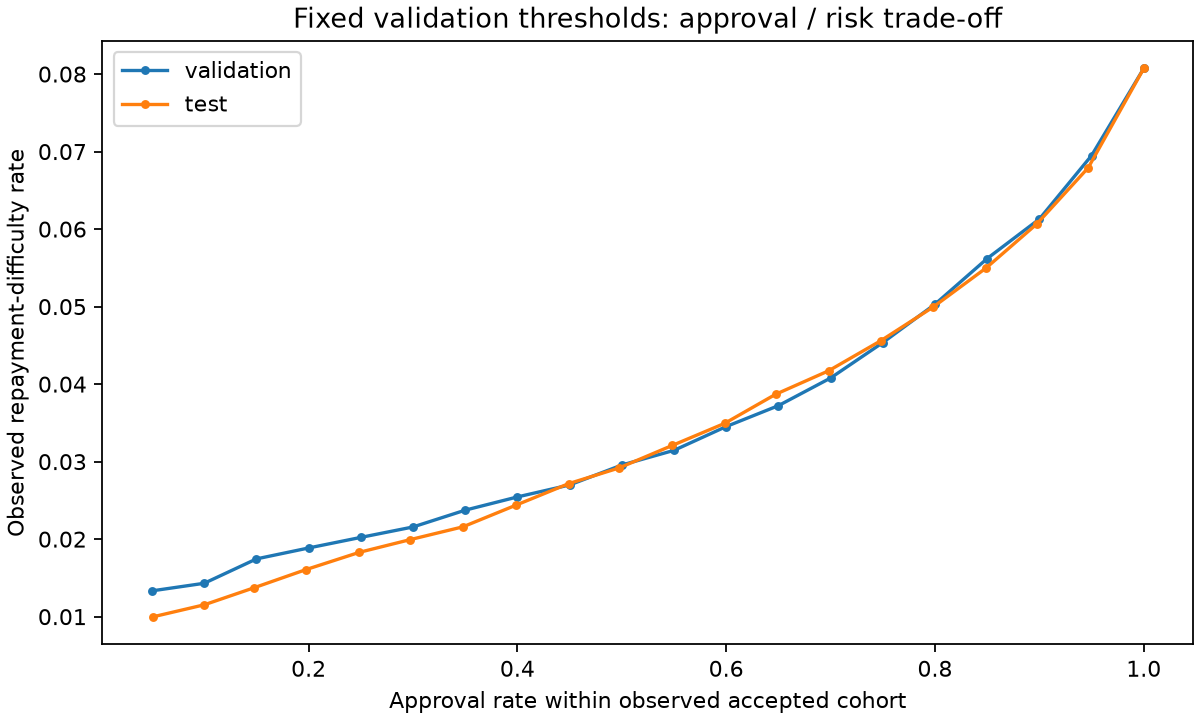

In [2]:
cutoffs = pd.read_csv(OUTPUT / 'cutoff_table.csv')
comparisons = pd.read_csv(OUTPUT / 'strategy_comparisons.csv')
display(cutoffs)
display(comparisons)
display(Image(filename=str(OUTPUT / 'figures' / 'strategy_tradeoff.png')))

## Answer: 10% more approvals

Compare the 50% and 55% requested policies with the fixed test thresholds. Approval/bad-rate intervals come from observed accepted-cohort outcomes; expected loss is a model-and-assumption scenario. No test-derived optimization or outcome-based acceptance decision is made.

In [3]:
row = comparisons[(comparisons.scenario == '10_percent_more_approvals_relative') & (comparisons.split == 'test')].iloc[0]
display(Markdown(f'Fixed thresholds approve **{row.baseline_actual_approval_rate:.2%} → {row.scenario_actual_approval_rate:.2%}** on test. '
    f'Observed TARGET rate among approved applicants is **{row.baseline_bad_rate:.2%} → {row.scenario_bad_rate:.2%}** '
    f'(**{row.bad_rate_change_percentage_points:+.2f} percentage points**). '
    f'Scenario expected-loss change: **{row.expected_loss_change:,.2f} dataset currency units**.'))

Fixed thresholds approve **49.71% → 54.86%** on test. Observed TARGET rate among approved applicants is **2.92% → 3.21%** (**+0.29 percentage points**). Scenario expected-loss change: **49,681,610.77 dataset currency units**.

## Reject inference and expected-loss assumptions

Only current accepted-applicant outcomes are observed. Previously rejected current applicants have no outcome, so these curves cannot say what happens when lending to them. Refusal history is a feature, not a substitute for missing rejected outcomes. Expected loss is PD × assumed LGD × EAD, using current credit as the exposure proxy. LGD is configurable (default 45%) and is not estimated from recoveries; execution preserves the completed analysis's LGD. TARGET records repayment difficulty, not confirmed loss. Known/missing EAD counts and EL coverage accompany each policy. Loss is a known-EAD subtotal when coverage is incomplete and is unavailable for a nonempty all-missing-EAD portfolio. The all-approved denominator and known-EAD-only denominator are labeled separately. Neither scenario EL nor its differences are accounting loss forecasts.

In [4]:
display(Markdown((OUTPUT / 'findings.md').read_text()))

# Credit-risk analysis findings

**Data status: REAL.** Computed from the supplied applicant feature export.

The export contains 307,511 applicants; 24,825 have TARGET=1. The observed repayment-difficulty rate is 8.07% (95% Wilson interval 7.98%–8.17%). TARGET is a repayment-difficulty proxy, not a verified loss or an independently established default event.

## Model and risk drivers

The scorecard uses transparent train-only Weight of Evidence bins and unweighted regularized logistic regression. Strongest univariate train associations: ext_source_3 (IV 0.303), ext_source_2 (IV 0.278), ext_source_1 (IV 0.140), employed_years (IV 0.108), occupation_type (IV 0.082). Associations and odds ratios are descriptive and conditional, not causal. All feature selection, clipping, rare-level pooling and WoE mappings use only the training 60%; validation (20%) defines decile boundaries and approval thresholds. Test (20%) is reserved for evaluation.

On the untouched test split, ROC AUC is 0.7511, KS is 0.3701, Gini is 0.5023 and Brier score is 0.0685. Mean predicted PD is 8.11%, compared with observed TARGET rate 8.07%. Inspect the calibration curve and bin counts; rare events and small bands have wide intervals. These are point estimates on one random split, with no temporal validation. The test set was not used to calibrate, select features, tune the model, define bands or choose cutoffs.

Risk bands ascend in predicted risk by construction. Observed rates are audited rather than forced into monotonicity: validation: 0 observed adjacent nonempty-band reversals; test: 0 observed adjacent nonempty-band reversals. Repeated prediction thresholds can leave empty bands; all ten band numbers remain in the export. A reversal is reported transparently and does not trigger a refit using test outcomes.

## Stakeholder question: 10% more approvals

The illustrative baseline requests 50% approval on validation predictions. Ten percent more approvals **relative** requests 55%; ten **percentage points** requests 60%, and both scenarios are exported. On test, the fixed 50%/55% validation thresholds approve 49.71%/54.86% of the accepted cohort. The observed bad rate changes from 2.92% to 3.21%, a change of +0.29 percentage points. Scenario expected loss changes by 49,681,610.77 dataset currency units. Actual approvals can differ from requested approvals because threshold ties and population variation are retained; no test outcomes determine the thresholds. See cutoff_table.csv for rate confidence intervals and strategy_comparisons.csv for both interpretations.

## Interpretation limits

- **Reject inference:** outcomes for rejected current applicants are unavailable. These retrospective policies re-rank the observed accepted cohort; they do not estimate the outcome of accepting previously rejected customers. Historical refused applications supply behavior features, not outcomes of rejected current applications.
- **Expected loss:** PD × assumed LGD 45% × EAD. EAD uses nonnegative current credit amount as a proxy; missing/invalid EAD produces missing applicant EL and is excluded from known-EAD portfolio subtotals. The export has 0 missing EAD values. Cutoff and band tables report known/missing EAD counts and EL coverage. A nonempty portfolio with entirely missing EAD has unavailable EL, and its strategy comparison remains unavailable; an empty approved portfolio has zero EL. `expected_loss_per_approved` divides the known-EAD EL subtotal by all approved applicants, while `expected_loss_per_approved_known_ead` divides it by applicants with known EAD. Neither is a complete-portfolio estimate when coverage is below 100%. LGD is a configurable scenario assumption, not a value learned from recoveries. These figures are not calibrated accounting loss estimates or a claim about currency conversion.
- **Time and population:** the data do not provide a usable current-application calendar for this pipeline, so random stratified validation cannot establish future performance. Relative-day/month history must already be filtered at the application observation point by SQL.
- **Confidence intervals and tests:** Wilson intervals describe observed binomial TARGET rates; they do not include model, LGD or EAD uncertainty. Chi-square p-values use asymptotic assumptions; sparse expected counts are flagged and all exploratory feature tests use Benjamini–Hochberg correction. Train-selected continuous bins make these tests exploratory. Large samples can make weak effects significant; inspect Cramér's V.
- **Score units:** score 600 represents good:bad odds 50:1 and 20 points double those odds. Higher scores are safer. Odds ratios are per +1 WoE (log good-distribution/bad-distribution), not per year or currency unit. Positive/negative coefficients can be affected by correlated features.
- **Selection and fairness:** historical lending policy shapes this cohort. The model is an educational demonstration and has not been reviewed for fairness, credit-policy compliance or live lending use.

## Reproducibility

Input SHA-256: `e9729cd0faf80ccb960a7eceb446842260947bfa31961a91c96c05d085544f69`. Random seed: 42. Model: woe-logistic-v1. Training-selected features: 25. Preprocessor and model are saved together; model_manifest.json records split sizes, clipping rules, WoE interpretation and nine validation boundaries. No manual outcome-based reordering or rejection-outcome imputation was performed.
